In [2]:
# ── Bootstrap: locate src/ relative to this notebook ─────────────────────
import sys, os

_here           = os.getcwd()                       # .../notebooks/
_root_candidate = os.path.dirname(_here)            # .../project_root/
for _p in [os.path.join(_here, 'src'),
           os.path.join(_root_candidate, 'src')]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break

# ── Shared path resolver (from src/) ─────────────────────────────────────
from path_config import PROJECT_ROOT, DATA_DIR, make_output_dir, data_path, print_paths
print_paths()

OUTPUT_DIR = make_output_dir('project3')
print(f'\n📁 Outputs : {OUTPUT_DIR}')

# ── Third-party ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
import seaborn as sns
from scipy import stats

# ── Global plot style ─────────────────────────────────────────────────────
PALETTE = {
    'hot'      : '#E53935',
    'cold'     : '#1E88E5',
    'rain'     : '#43A047',
    'wind'     : '#8E24AA',
    'neutral'  : '#FB8C00',
    'bg'       : '#F8F9FA',
    'grid'     : '#E0E0E0',
}
SEASON_COLORS  = {'Winter':'#1E88E5','Spring':'#43A047','Summer':'#E53935','Fall':'#FB8C00'}
MONTH_ABBR     = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': PALETTE['bg'],
    'axes.facecolor'  : PALETTE['bg'],
    'grid.color'      : PALETTE['grid'],
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.7,
    'figure.dpi'      : 120,
})

print('\n✅ All imports successful.')


📁 Project root : /Users/tejaspatil/Documents/Data Analysis Portfolio
📁 src/         : /Users/tejaspatil/Documents/Data Analysis Portfolio/src  (on sys.path)
📁 data/        : /Users/tejaspatil/Documents/Data Analysis Portfolio/data

📁 Outputs : /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project3

✅ All imports successful.


In [3]:
DATA_PATH = data_path('climate_data.csv')
print(f'Loading: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
print(f'\n✅ Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()


Loading: /Users/tejaspatil/Documents/Data Analysis Portfolio/data/climate_data.csv

✅ Loaded 3,902 rows × 23 columns


,Date,Average temperature (°F),Average humidity (%),Average dewpoint (°F),Average barometer (in),Average windspeed (mph),Average gustspeed (mph),Average direction (°deg),Rainfall for month (in),Rainfall for year (in),...,Maximum humidity (%),Minimum humidity (%),Maximum pressure,Minimum pressure,Maximum windspeed (mph),Maximum gust speed (mph),Maximum heat index (°F),Date1,Month,diff_pressure
0,2009-01-01,37.8,35.0,12.7,29.7,26.4,36.8,274.0,0.0,0.0,...,4.0,27.0,29.762,29.596,41.4,59.0,40.0,2009-01-01,1,0.166
1,2009-01-02,43.2,32.0,14.7,29.5,12.8,18.0,240.0,0.0,0.0,...,4.0,16.0,29.669,29.268,35.7,51.0,52.0,2009-01-02,1,0.401
2,2009-01-03,25.7,60.0,12.7,29.7,8.3,12.2,290.0,0.0,0.0,...,8.0,35.0,30.232,29.260,25.3,38.0,41.0,2009-01-03,1,0.972
3,2009-01-04,9.3,67.0,0.1,30.4,2.9,4.5,47.0,0.0,0.0,...,7.0,35.0,30.566,30.227,12.7,20.0,32.0,2009-01-04,1,0.339
4,2009-01-05,23.5,30.0,-5.3,29.9,16.7,23.1,265.0,0.0,0.0,...,5.0,13.0,30.233,29.568,38.0,53.0,32.0,2009-01-05,1,0.665


In [4]:
print('Column inventory:')
for i, (col, dtype) in enumerate(df_raw.dtypes.items()):
    null_pct = df_raw[col].isnull().mean() * 100
    print(f'  {i:2d}  {col:<40s}  {str(dtype):<10s}  nulls={null_pct:.1f}%')


Column inventory:
   0  Date                                      object      nulls=0.0%
   1  Average temperature (°F)                  float64     nulls=0.0%
   2  Average humidity (%)                      float64     nulls=0.0%
   3  Average dewpoint (°F)                     float64     nulls=0.0%
   4  Average barometer (in)                    float64     nulls=0.0%
   5  Average windspeed (mph)                   float64     nulls=0.0%
   6  Average gustspeed (mph)                   float64     nulls=0.0%
   7  Average direction (°deg)                  float64     nulls=0.0%
   8  Rainfall for month (in)                   float64     nulls=0.0%
   9  Rainfall for year (in)                    float64     nulls=0.0%
  10  Maximum rain per minute                   float64     nulls=0.0%
  11  Maximum temperature (°F)                  float64     nulls=0.0%
  12  Minimum temperature (°F)                  float64     nulls=0.0%
  13  Maximum humidity (%)                      float64    

In [5]:
df = df_raw.copy()

# ── 2.1 Parse date ────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Drop redundant date/month columns that came with the raw CSV
df.drop(columns=[c for c in ['Date1','Month'] if c in df.columns],
        inplace=True)

# ── 2.2 Rename columns for convenience ───────────────────────────────────
RENAME = {
    'Average temperature (°F)'  : 'avg_temp',
    'Average humidity (%)'       : 'avg_humidity',
    'Average dewpoint (°F)'      : 'avg_dewpoint',
    'Average barometer (in)'     : 'avg_pressure',
    'Average windspeed (mph)'    : 'avg_windspeed',
    'Average gustspeed (mph)'    : 'avg_gustspeed',
    'Average direction (°deg)'   : 'wind_direction',
    'Rainfall for month (in)'    : 'rainfall_month',
    'Rainfall for year (in)'     : 'rainfall_year',
    'Maximum rain per minute'    : 'max_rain_per_min',
    'Maximum temperature (°F)'   : 'max_temp',
    'Minimum temperature (°F)'   : 'min_temp',
    'Maximum humidity (%)'       : 'max_humidity',
    'Minimum humidity (%)'       : 'min_humidity',
    'Maximum pressure'           : 'max_pressure',
    'Minimum pressure'           : 'min_pressure',
    'Maximum windspeed (mph)'    : 'max_windspeed',
    'Maximum gust speed (mph)'   : 'max_gustspeed',
    'Maximum heat index (°F)'    : 'max_heat_index',
    'diff_pressure'              : 'diff_pressure',
}
df.rename(columns=RENAME, inplace=True)

# ── 2.3 Derived time features ─────────────────────────────────────────────
df['year']       = df['Date'].dt.year
df['month']      = df['Date'].dt.month
df['month_name'] = df['Date'].dt.strftime('%b')
df['day_of_year']= df['Date'].dt.dayofyear
df['week']       = df['Date'].dt.isocalendar().week.astype(int)

def assign_season(month):
    if month in [12,1,2]:  return 'Winter'
    if month in [3,4,5]:   return 'Spring'
    if month in [6,7,8]:   return 'Summer'
    return 'Fall'

df['season'] = df['month'].apply(assign_season)

# ── 2.4 Derived weather features ──────────────────────────────────────────
df['temp_range']   = df['max_temp']  - df['min_temp']
df['humid_range']  = df['max_humidity'] - df['min_humidity']
df['has_rain']     = df['rainfall_month'] > 0
df['heat_stress']  = df['max_heat_index'] >= 90    # NOAA definition

# Extreme flags (outside 5th–95th percentile)
lo, hi = df['avg_temp'].quantile(0.05), df['avg_temp'].quantile(0.95)
df['extreme_cold'] = df['avg_temp'] < lo
df['extreme_heat'] = df['avg_temp'] > hi

print(f'✅ Cleaning complete. Shape: {df.shape}')
print(f'   Date range  : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'   Years       : {sorted(df.year.unique())}')
print(f'   Seasons     : {df.season.value_counts().to_dict()}')
print(f'   Extreme cold: {df.extreme_cold.sum()} days')
print(f'   Extreme heat: {df.extreme_heat.sum()} days')
df.head()


✅ Cleaning complete. Shape: (3902, 33)
   Date range  : 2009-01-01 → 2020-07-28
   Years       : [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
   Seasons     : {'Summer': 1024, 'Spring': 976, 'Winter': 955, 'Fall': 947}
   Extreme cold: 194 days
   Extreme heat: 195 days


,Date,avg_temp,avg_humidity,avg_dewpoint,avg_pressure,avg_windspeed,avg_gustspeed,wind_direction,rainfall_month,rainfall_year,...,month_name,day_of_year,week,season,temp_range,humid_range,has_rain,heat_stress,extreme_cold,extreme_heat
0,2009-01-01,37.8,35.0,12.7,29.7,26.4,36.8,274.0,0.0,0.0,...,Jan,1,1,Winter,6.0,-23.0,False,False,False,False
1,2009-01-02,43.2,32.0,14.7,29.5,12.8,18.0,240.0,0.0,0.0,...,Jan,2,1,Winter,15.0,-12.0,False,False,False,False
2,2009-01-03,25.7,60.0,12.7,29.7,8.3,12.2,290.0,0.0,0.0,...,Jan,3,1,Winter,35.0,-27.0,False,False,False,False
3,2009-01-04,9.3,67.0,0.1,30.4,2.9,4.5,47.0,0.0,0.0,...,Jan,4,1,Winter,19.0,-28.0,False,False,True,False
4,2009-01-05,23.5,30.0,-5.3,29.9,16.7,23.1,265.0,0.0,0.0,...,Jan,5,2,Winter,15.0,-8.0,False,False,False,False


In [6]:
KEY_COLS = ['avg_temp','max_temp','min_temp','avg_humidity',
            'avg_dewpoint','avg_pressure','avg_windspeed',
            'avg_gustspeed','rainfall_month','max_heat_index']

desc = df[KEY_COLS].describe().T
desc['skew'] = df[KEY_COLS].skew().round(3)
desc['iqr']  = (df[KEY_COLS].quantile(0.75) - df[KEY_COLS].quantile(0.25)).round(2)
desc = desc.round(2)
desc.style.background_gradient(cmap='RdYlBu_r', subset=['mean']).format('{:.2f}')


,count,mean,std,min,25%,50%,75%,max,skew,iqr
avg_temp,3902.00,44.67,15.33,-12.10,33.70,45.10,58.00,76.30,-0.39,24.30
max_temp,3902.00,57.56,17.76,-6.10,43.90,57.25,73.20,92.70,-0.21,29.30
min_temp,3902.00,31.23,14.12,-27.70,23.00,32.80,41.80,65.70,-0.67,18.80
avg_humidity,3902.00,48.88,17.44,9.00,36.00,47.00,61.00,94.00,0.27,25.00
avg_dewpoint,3902.00,23.13,14.63,-22.20,12.10,22.50,35.40,55.10,-0.06,23.30
avg_pressure,3902.00,29.88,0.25,28.20,29.70,29.90,30.00,31.00,0.27,0.30
avg_windspeed,3902.00,5.76,4.02,0.00,2.70,4.60,8.00,26.40,1.13,5.30
avg_gustspeed,3902.00,10.01,14.12,0.00,4.50,7.10,12.10,240.40,9.11,7.60
rainfall_month,3902.00,0.45,0.60,0.00,0.05,0.22,0.67,4.48,2.47,0.62
max_heat_index,3902.00,58.09,17.95,-6.10,43.90,57.20,77.30,88.40,-0.26,33.40


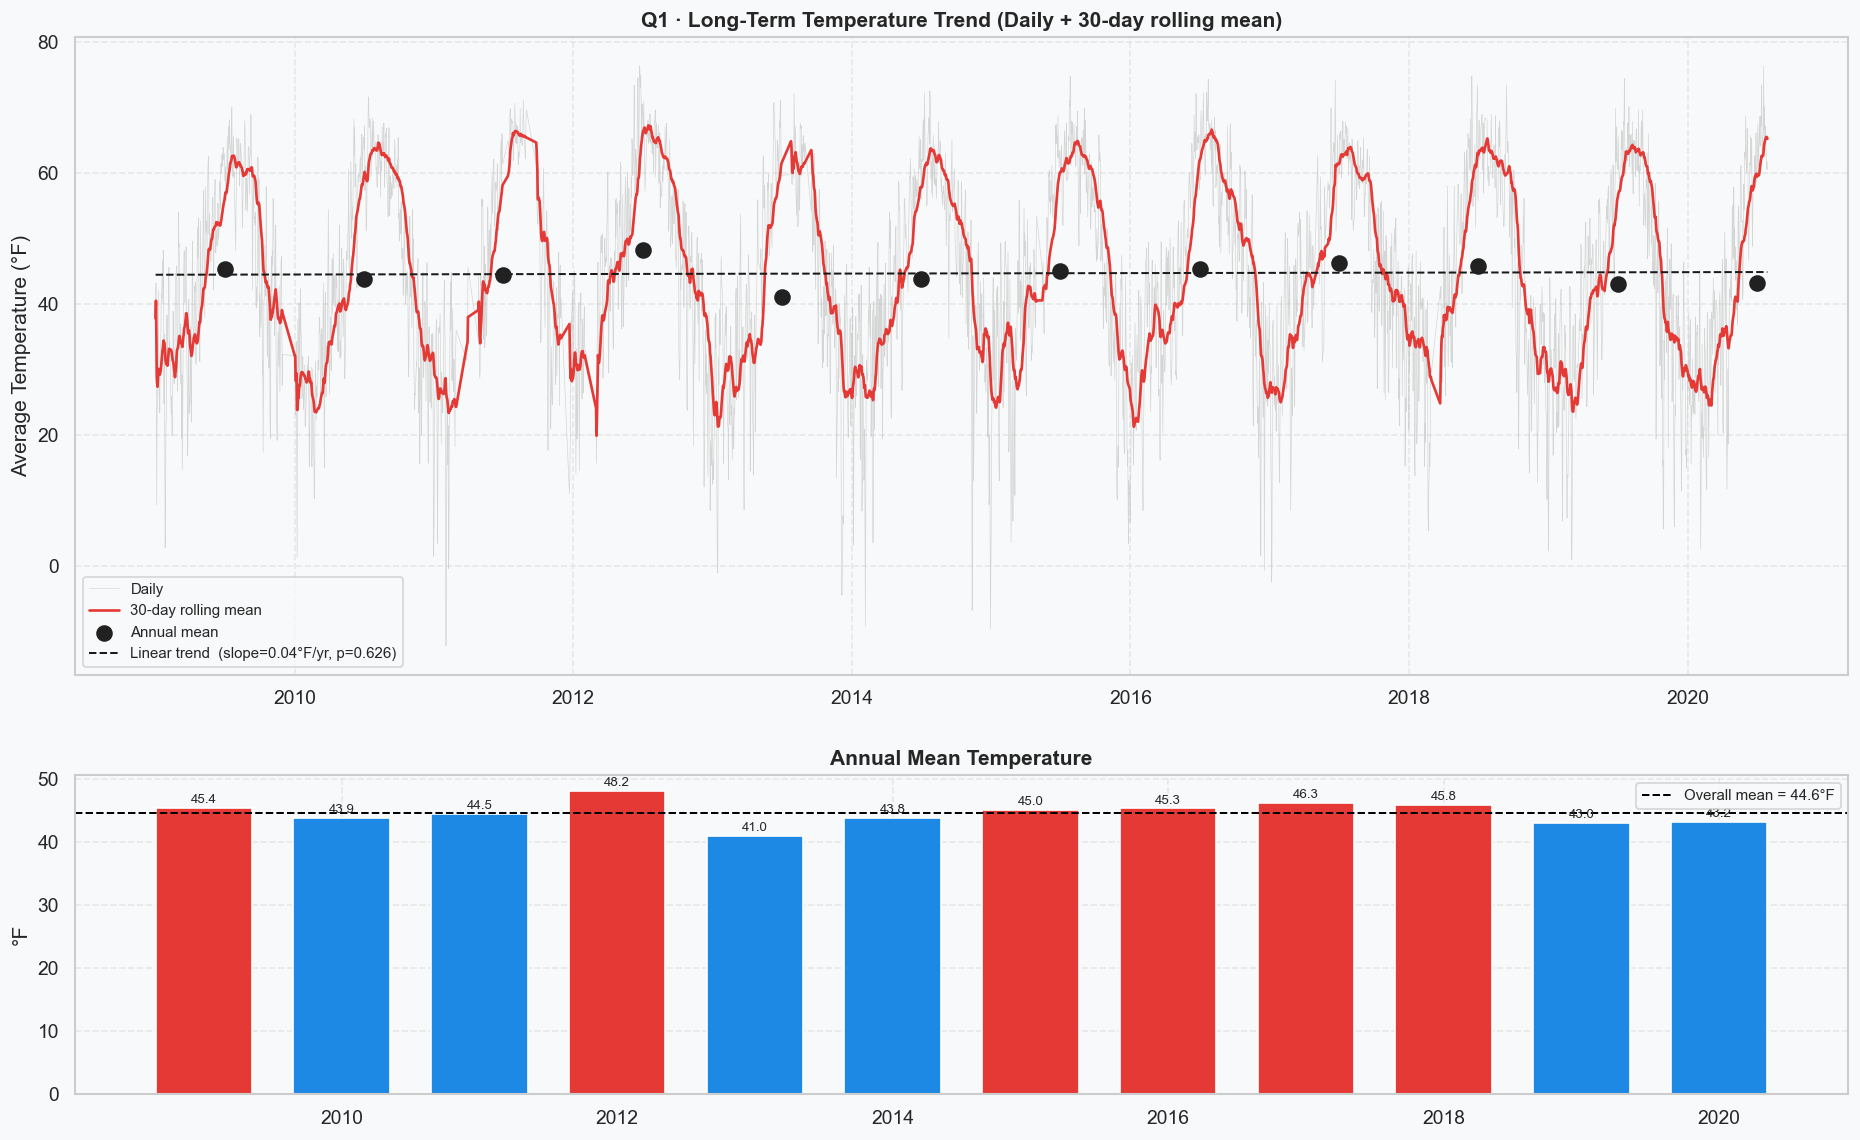

📈 Trend: 0.036 °F/year  |  R²=0.000  |  p=0.6256


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios':[2,1]})

# ── Panel 1: daily rolling average + annual mean band ────────────────────
ax = axes[0]
roll30 = df.set_index('Date')['avg_temp'].rolling('30D').mean()
ax.plot(df['Date'], df['avg_temp'], color='#BDBDBD', linewidth=0.4, alpha=0.6, label='Daily')
ax.plot(roll30.index, roll30.values, color=PALETTE['hot'], linewidth=1.6, label='30-day rolling mean')

# Annual means as scatter
ann = df.groupby('year')['avg_temp'].mean()
ann_dates = pd.to_datetime([f'{y}-07-01' for y in ann.index])
ax.scatter(ann_dates, ann.values, s=80, color='#212121', zorder=5, label='Annual mean')

# Linear trend
x_num = mdates.date2num(df['Date'])
slope, intercept, r, p, _ = stats.linregress(x_num, df['avg_temp'])
trend_y = slope * x_num + intercept
ax.plot(df['Date'], trend_y, 'k--', linewidth=1.2,
        label=f'Linear trend  (slope={slope*365:.2f}°F/yr, p={p:.3f})')

ax.set_title('Q1 · Long-Term Temperature Trend (Daily + 30-day rolling mean)',
             fontweight='bold')
ax.set_ylabel('Average Temperature (°F)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# ── Panel 2: annual mean bar chart ───────────────────────────────────────
ax2 = axes[1]
colors_bar = [PALETTE['hot'] if v > ann.mean() else PALETTE['cold'] for v in ann.values]
bars = ax2.bar(ann.index, ann.values, color=colors_bar, edgecolor='white', width=0.7)
ax2.axhline(ann.mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Overall mean = {ann.mean():.1f}°F')
for bar, val in zip(bars, ann.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax2.set_title('Annual Mean Temperature', fontweight='bold')
ax2.set_ylabel('°F')
ax2.legend(fontsize=9)

fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q1_temperature_trend.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'📈 Trend: {slope*365:.3f} °F/year  |  R²={r**2:.3f}  |  p={p:.4f}')


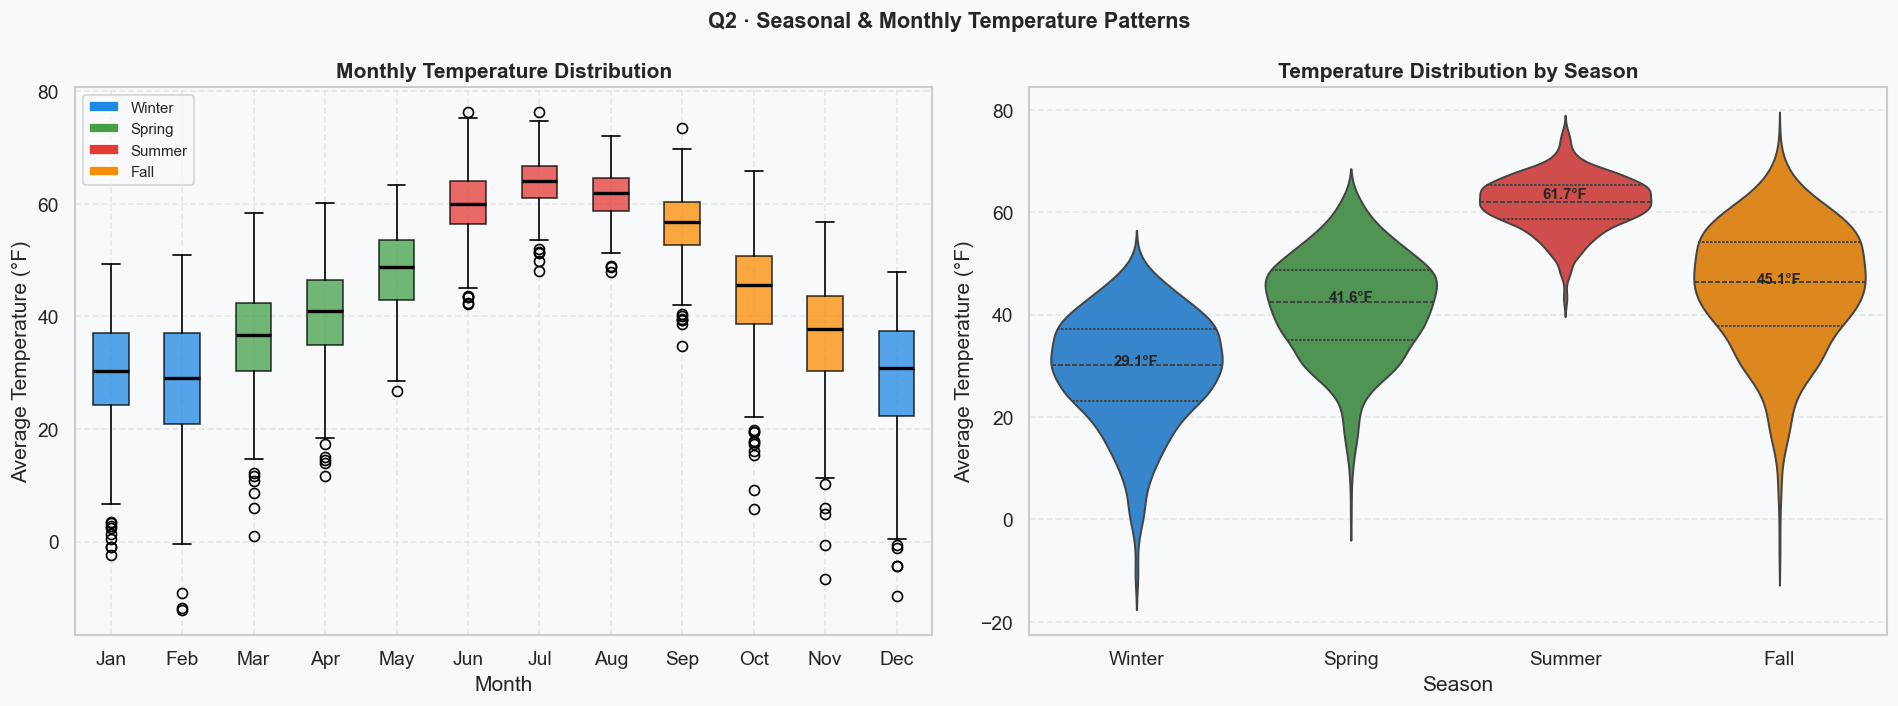

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: monthly box plots ───────────────────────────────────────────────
ax = axes[0]
month_order = list(range(1,13))
monthly_data = [df[df['month']==m]['avg_temp'].values for m in month_order]
bp = ax.boxplot(monthly_data, patch_artist=True, notch=False,
                medianprops={'color':'black','linewidth':2})

season_color_map = {1:'#1E88E5',2:'#1E88E5',3:'#43A047',4:'#43A047',5:'#43A047',
                    6:'#E53935',7:'#E53935',8:'#E53935',9:'#FB8C00',10:'#FB8C00',
                    11:'#FB8C00',12:'#1E88E5'}
for patch, m in zip(bp['boxes'], month_order):
    patch.set_facecolor(season_color_map[m])
    patch.set_alpha(0.75)

ax.set_xticklabels(MONTH_ABBR)
ax.set_title('Monthly Temperature Distribution', fontweight='bold')
ax.set_ylabel('Average Temperature (°F)')
ax.set_xlabel('Month')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=s)
              for s,c in SEASON_COLORS.items()]
ax.legend(handles=legend_els, fontsize=9, loc='upper left')

# ── Right: seasonal violin ────────────────────────────────────────────────
ax2 = axes[1]
season_order = ['Winter','Spring','Summer','Fall']
sns.violinplot(data=df, x='season', y='avg_temp', order=season_order,
               palette=SEASON_COLORS, ax=ax2, inner='quartile', linewidth=1.2)
ax2.set_title('Temperature Distribution by Season', fontweight='bold')
ax2.set_xlabel('Season')
ax2.set_ylabel('Average Temperature (°F)')

for s in season_order:
    m = df[df['season']==s]['avg_temp'].mean()
    xi = season_order.index(s)
    ax2.text(xi, m+1, f'{m:.1f}°F', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Q2 · Seasonal & Monthly Temperature Patterns', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q2_seasonal_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()


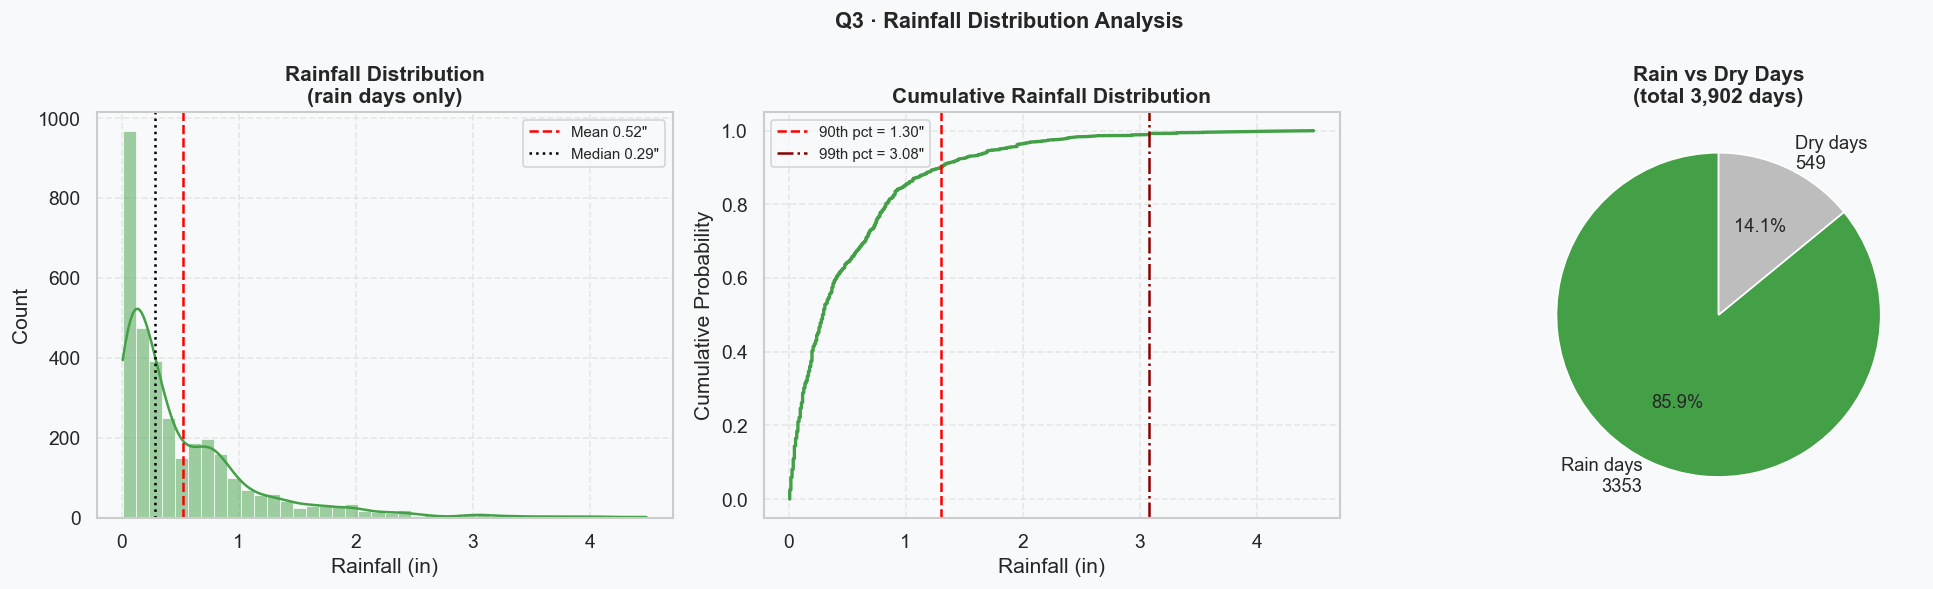

Total rain days  : 3353 (85.9%)
Mean rainfall    : 0.525"  (rain days only)
90th percentile  : 1.300"
99th percentile  : 3.080"


In [18]:
rain = df[df['rainfall_month'] > 0]['rainfall_month']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Histogram + KDE ──────────────────────────────────────────────────────
ax = axes[0]
sns.histplot(rain, bins=40, kde=True, ax=ax, color=PALETTE['rain'],
             edgecolor='white', linewidth=0.4)
ax.axvline(rain.mean(),   color='red',  linestyle='--', linewidth=1.5,
           label=f'Mean {rain.mean():.2f}"')
ax.axvline(rain.median(), color='black',linestyle=':',  linewidth=1.5,
           label=f'Median {rain.median():.2f}"')
ax.set_title('Rainfall Distribution\n(rain days only)', fontweight='bold')
ax.set_xlabel('Rainfall (in)')
ax.legend(fontsize=9)

# ── Cumulative distribution ───────────────────────────────────────────────
ax2 = axes[1]
sorted_rain = np.sort(rain)
cdf = np.arange(1, len(sorted_rain)+1) / len(sorted_rain)
ax2.plot(sorted_rain, cdf, color=PALETTE['rain'], linewidth=2)
ax2.axvline(rain.quantile(0.90), color='red', linestyle='--',
            label=f'90th pct = {rain.quantile(0.90):.2f}\"')
ax2.axvline(rain.quantile(0.99), color='darkred', linestyle='-.',
            label=f'99th pct = {rain.quantile(0.99):.2f}\"')
ax2.set_title('Cumulative Rainfall Distribution', fontweight='bold')
ax2.set_xlabel('Rainfall (in)')
ax2.set_ylabel('Cumulative Probability')
ax2.legend(fontsize=9)

# ── Rain-day vs dry-day pie ───────────────────────────────────────────────
ax3 = axes[2]
rain_days = df['has_rain'].sum()
dry_days  = (~df['has_rain']).sum()
ax3.pie([rain_days, dry_days],
        labels=[f'Rain days\n{rain_days}', f'Dry days\n{dry_days}'],
        colors=[PALETTE['rain'], '#BDBDBD'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':11})
ax3.set_title(f'Rain vs Dry Days\n(total {len(df):,} days)', fontweight='bold')

fig.suptitle('Q3 · Rainfall Distribution Analysis', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q3_rainfall_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Total rain days  : {rain_days} ({rain_days/len(df)*100:.1f}%)')
print(f'Mean rainfall    : {rain.mean():.3f}\"  (rain days only)')
print(f'90th percentile  : {rain.quantile(0.90):.3f}\"')
print(f'99th percentile  : {rain.quantile(0.99):.3f}\"')


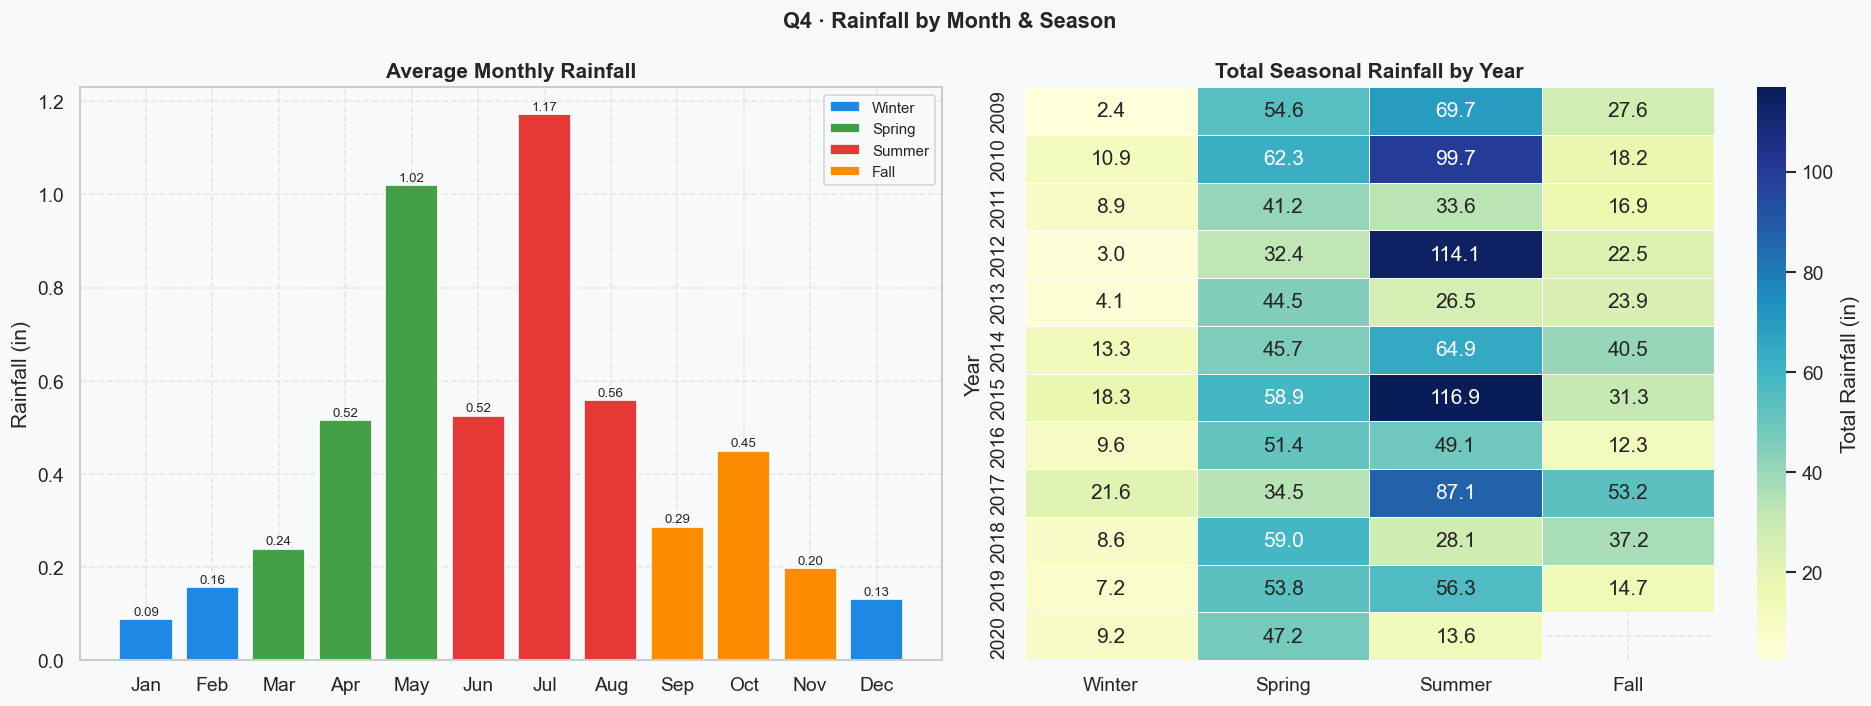

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Monthly average rainfall ──────────────────────────────────────────────
ax = axes[0]
monthly_rain = df.groupby('month')['rainfall_month'].mean()
colors_m = [season_color_map[m] for m in monthly_rain.index]
bars = ax.bar(MONTH_ABBR, monthly_rain.values, color=colors_m, edgecolor='white')
for bar, val in zip(bars, monthly_rain.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Average Monthly Rainfall', fontweight='bold')
ax.set_ylabel('Rainfall (in)')
ax.legend(handles=legend_els, fontsize=9)

# ── Seasonal heatmap by year ──────────────────────────────────────────────
ax2 = axes[1]
pivot = df.pivot_table(values='rainfall_month', index='year',
                       columns='season', aggfunc='sum')[season_order]
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=ax2,
            cbar_kws={'label':'Total Rainfall (in)'})
ax2.set_title('Total Seasonal Rainfall by Year', fontweight='bold')
ax2.set_ylabel('Year')
ax2.set_xlabel('')

fig.suptitle('Q4 · Rainfall by Month & Season', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q4_monthly_seasonal_rainfall.png'),
            dpi=150, bbox_inches='tight')
plt.show()


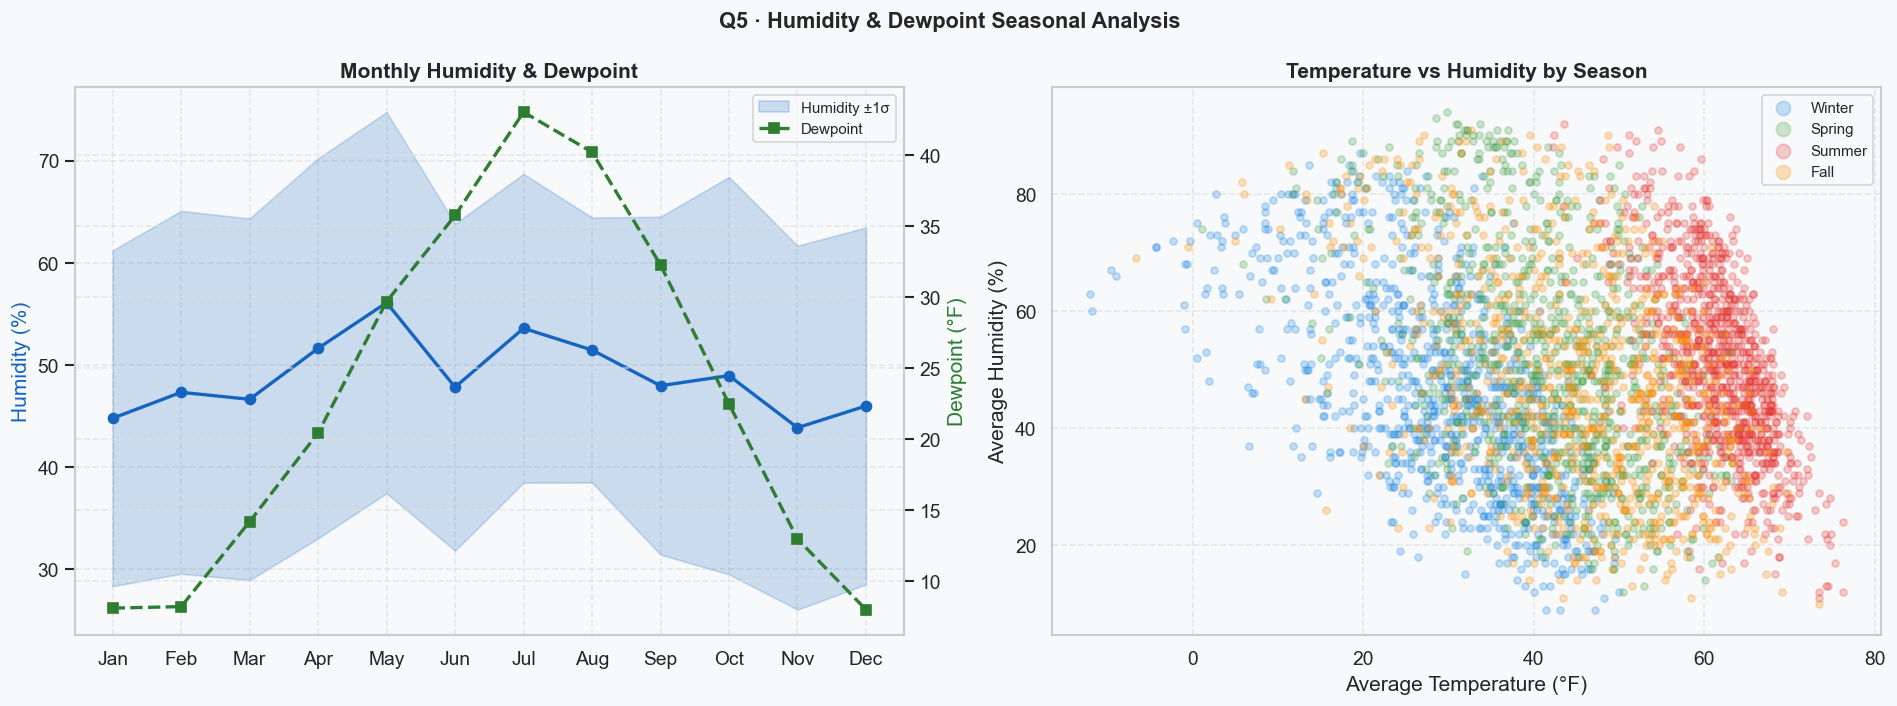

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Humidity by month (line + CI) ─────────────────────────────────────────
ax = axes[0]
monthly_hum = df.groupby('month')['avg_humidity'].agg(['mean','std'])
ax.plot(range(1,13), monthly_hum['mean'], 'o-', color='#1565C0', linewidth=2)
ax.fill_between(range(1,13),
                monthly_hum['mean'] - monthly_hum['std'],
                monthly_hum['mean'] + monthly_hum['std'],
                alpha=0.2, color='#1565C0', label='±1 std dev')
ax2 = ax.twinx()
monthly_dew = df.groupby('month')['avg_dewpoint'].mean()
ax2.plot(range(1,13), monthly_dew.values, 's--', color='#2E7D32',
         linewidth=2, label='Dewpoint')
ax2.set_ylabel('Dewpoint (°F)', color='#2E7D32')
ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTH_ABBR)
ax.set_ylabel('Humidity (%)', color='#1565C0')
ax.set_title('Monthly Humidity & Dewpoint', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, ['Humidity ±1σ','Dewpoint'], fontsize=9)

# ── Scatter: temp vs humidity coloured by season ──────────────────────────
ax3 = axes[1]
for s in season_order:
    sub = df[df['season']==s]
    ax3.scatter(sub['avg_temp'], sub['avg_humidity'],
                c=SEASON_COLORS[s], alpha=0.25, s=18, label=s)
ax3.set_xlabel('Average Temperature (°F)')
ax3.set_ylabel('Average Humidity (%)')
ax3.set_title('Temperature vs Humidity by Season', fontweight='bold')
ax3.legend(fontsize=9, markerscale=2)

fig.suptitle('Q5 · Humidity & Dewpoint Seasonal Analysis', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q5_humidity_dewpoint.png'),
            dpi=150, bbox_inches='tight')
plt.show()


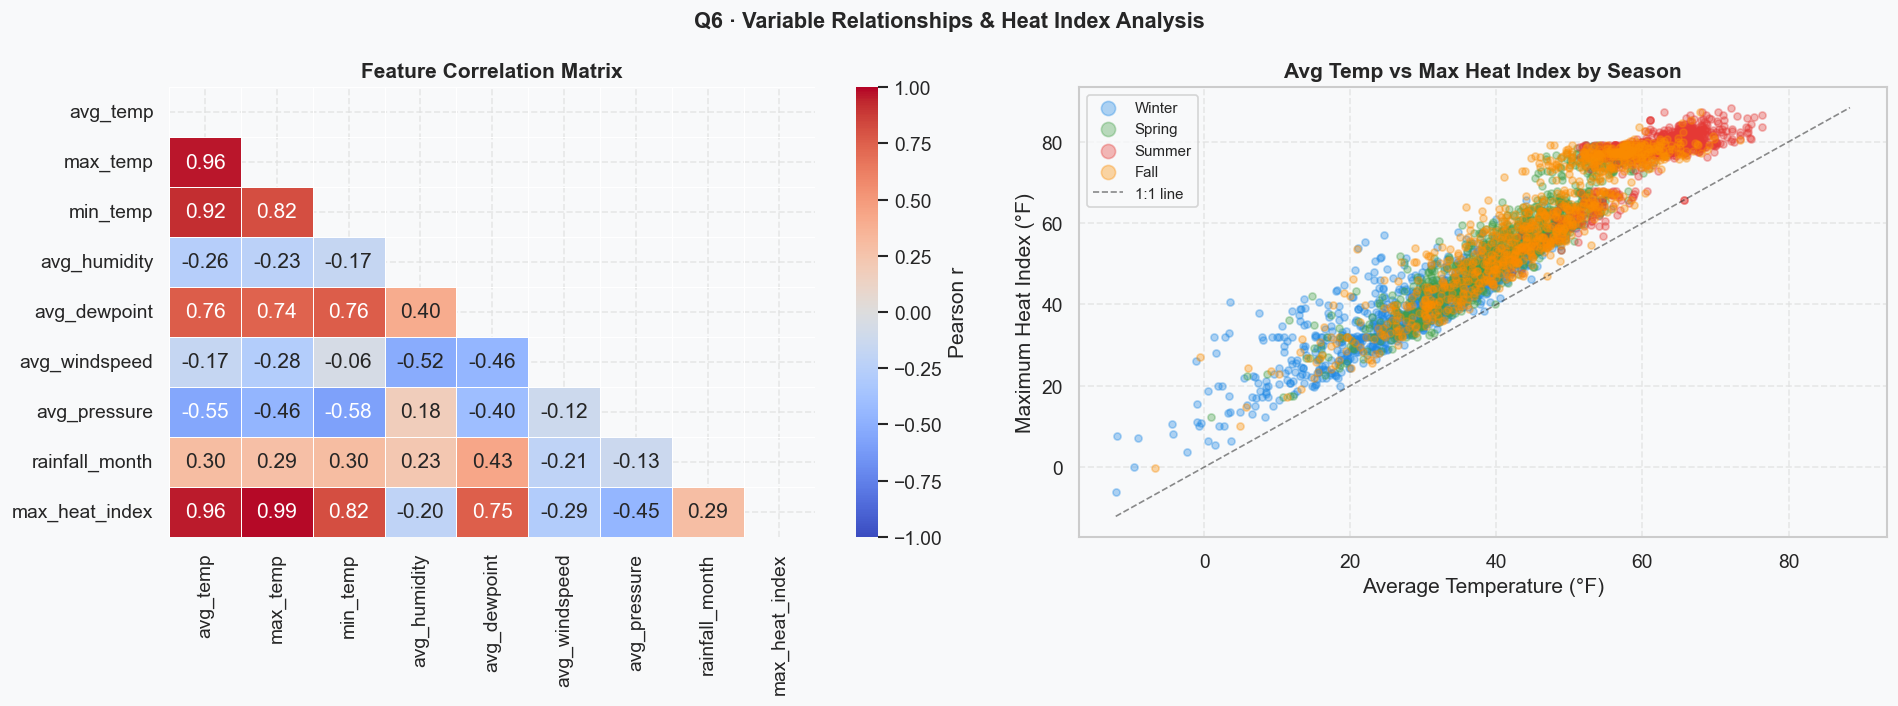

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Correlation matrix ────────────────────────────────────────────────────
ax = axes[0]
corr_cols = ['avg_temp','max_temp','min_temp','avg_humidity','avg_dewpoint',
             'avg_windspeed','avg_pressure','rainfall_month','max_heat_index']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label':'Pearson r'})
ax.set_title('Feature Correlation Matrix', fontweight='bold')

# ── Temp vs Heat Index scatter ────────────────────────────────────────────
ax2 = axes[1]
for s in season_order:
    sub = df[df['season']==s]
    ax2.scatter(sub['avg_temp'], sub['max_heat_index'],
                c=SEASON_COLORS[s], alpha=0.35, s=18, label=s)
# 1:1 line
lims = [min(df['avg_temp'].min(), df['max_heat_index'].min()),
        max(df['avg_temp'].max(), df['max_heat_index'].max())]
ax2.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='1:1 line')
ax2.set_xlabel('Average Temperature (°F)')
ax2.set_ylabel('Maximum Heat Index (°F)')
ax2.set_title('Avg Temp vs Max Heat Index by Season', fontweight='bold')
ax2.legend(fontsize=9, markerscale=2)

fig.suptitle('Q6 · Variable Relationships & Heat Index Analysis', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q6_correlation_heatindex.png'),
            dpi=150, bbox_inches='tight')
plt.show()


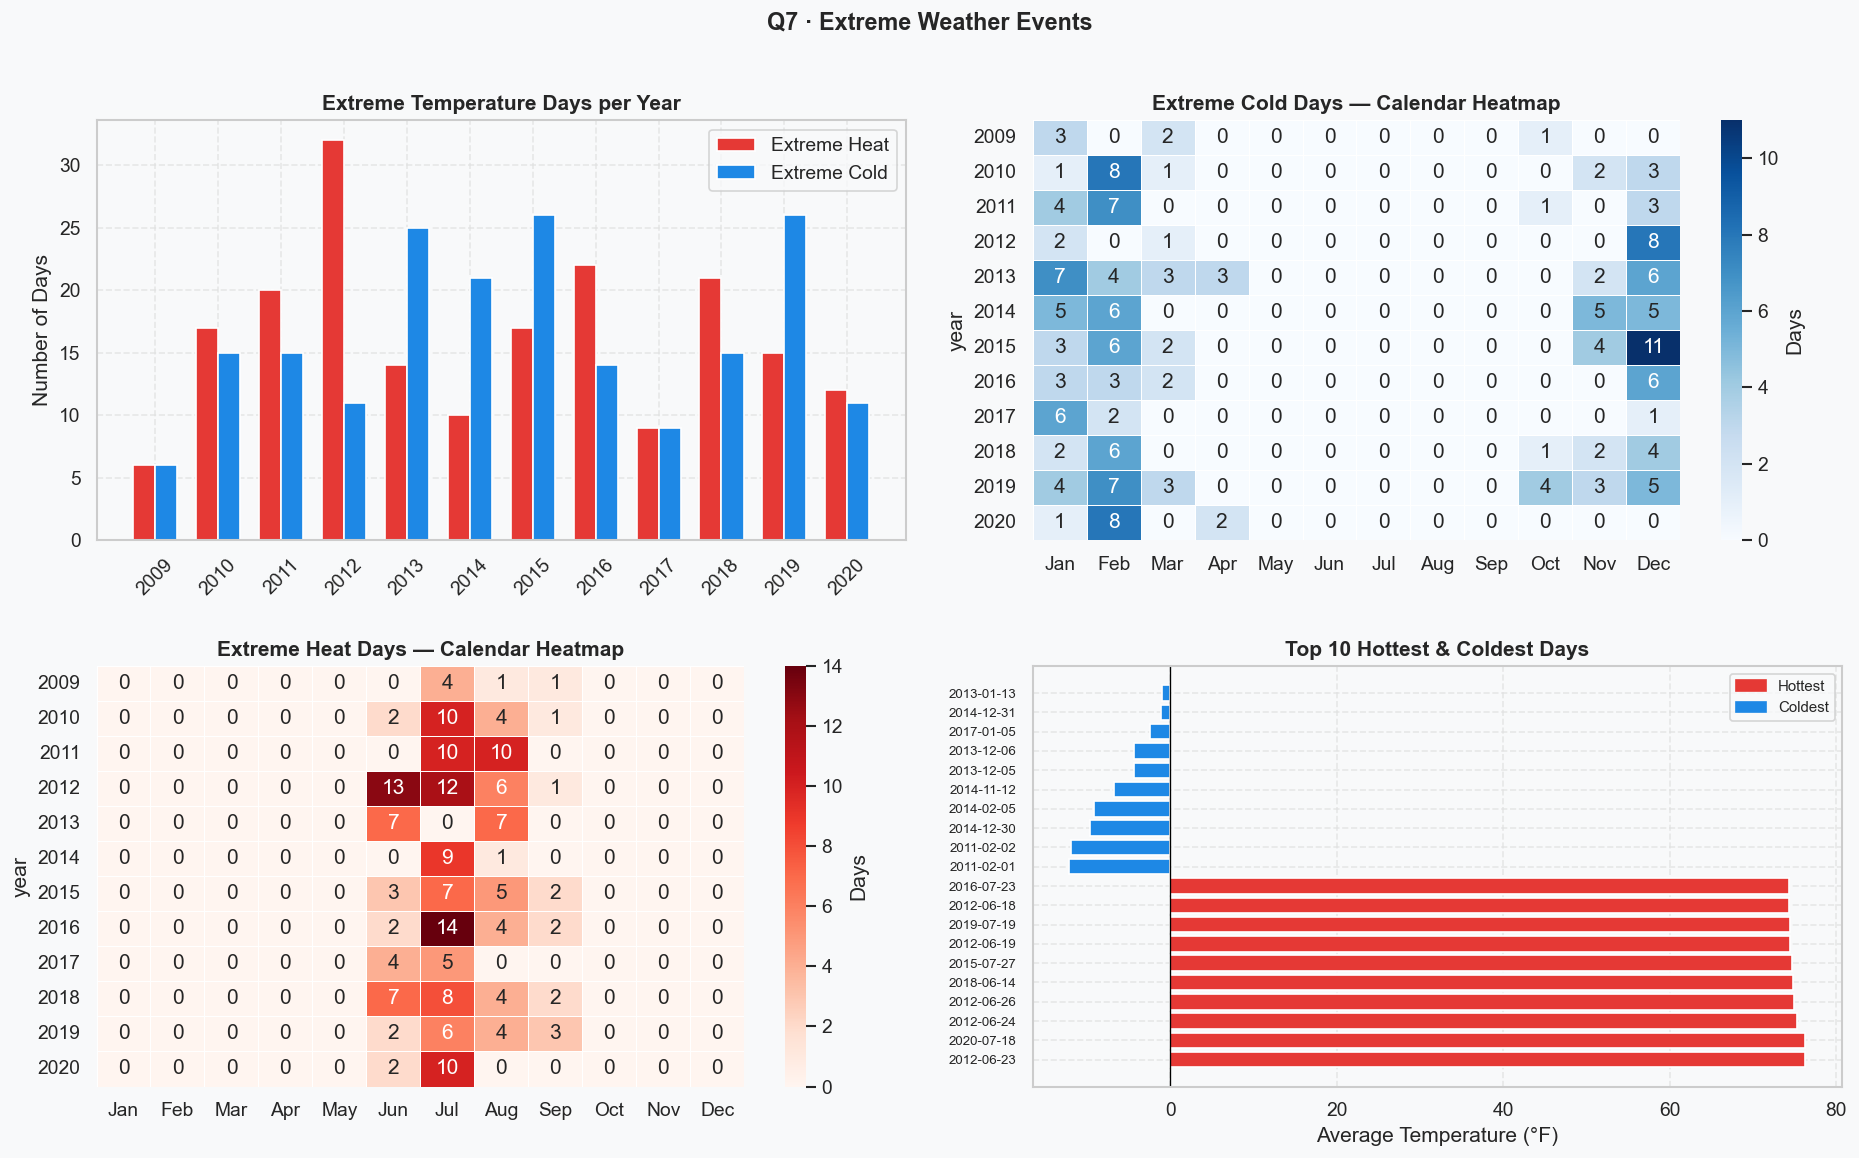

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Top-left: extreme days per year ──────────────────────────────────────
ax = axes[0,0]
ext = df.groupby('year')[['extreme_heat','extreme_cold']].sum()
x = np.arange(len(ext))
w = 0.35
ax.bar(x-w/2, ext['extreme_heat'], w, color=PALETTE['hot'],  label='Extreme Heat', edgecolor='white')
ax.bar(x+w/2, ext['extreme_cold'], w, color=PALETTE['cold'], label='Extreme Cold', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(ext.index, rotation=45)
ax.set_title('Extreme Temperature Days per Year', fontweight='bold')
ax.set_ylabel('Number of Days')
ax.legend()

# ── Top-right: calendar heatmap of extreme cold ───────────────────────────
ax2 = axes[0,1]
pivot_cold = df.pivot_table(values='extreme_cold', index='year',
                            columns='month', aggfunc='sum').fillna(0)
pivot_cold.columns = MONTH_ABBR
sns.heatmap(pivot_cold, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax2, cbar_kws={'label':'Days'})
ax2.set_title('Extreme Cold Days — Calendar Heatmap', fontweight='bold')

# ── Bottom-left: calendar heatmap of extreme heat ─────────────────────────
ax3 = axes[1,0]
pivot_heat = df.pivot_table(values='extreme_heat', index='year',
                            columns='month', aggfunc='sum').fillna(0)
pivot_heat.columns = MONTH_ABBR
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.5, ax=ax3, cbar_kws={'label':'Days'})
ax3.set_title('Extreme Heat Days — Calendar Heatmap', fontweight='bold')

# ── Bottom-right: top-10 hottest and coldest days ─────────────────────────
ax4 = axes[1,1]
top_hot  = df.nlargest(10,'avg_temp')[['Date','avg_temp']]
top_cold = df.nsmallest(10,'avg_temp')[['Date','avg_temp']]
y_pos_h = np.arange(10)
y_pos_c = np.arange(10, 20)
ax4.barh(y_pos_h, top_hot['avg_temp'].values,  color=PALETTE['hot'],  edgecolor='white')
ax4.barh(y_pos_c, top_cold['avg_temp'].values, color=PALETTE['cold'], edgecolor='white')
ax4.set_yticks(list(y_pos_h)+list(y_pos_c))
ax4.set_yticklabels(
    [d.strftime('%Y-%m-%d') for d in top_hot['Date']] +
    [d.strftime('%Y-%m-%d') for d in top_cold['Date']],
    fontsize=8
)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('Top 10 Hottest & Coldest Days', fontweight='bold')
ax4.set_xlabel('Average Temperature (°F)')
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(color=PALETTE['hot'],label='Hottest'),
                    Patch(color=PALETTE['cold'],label='Coldest')], fontsize=9)

fig.suptitle('Q7 · Extreme Weather Events', fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q7_extreme_events.png'),
            dpi=150, bbox_inches='tight')
plt.show()


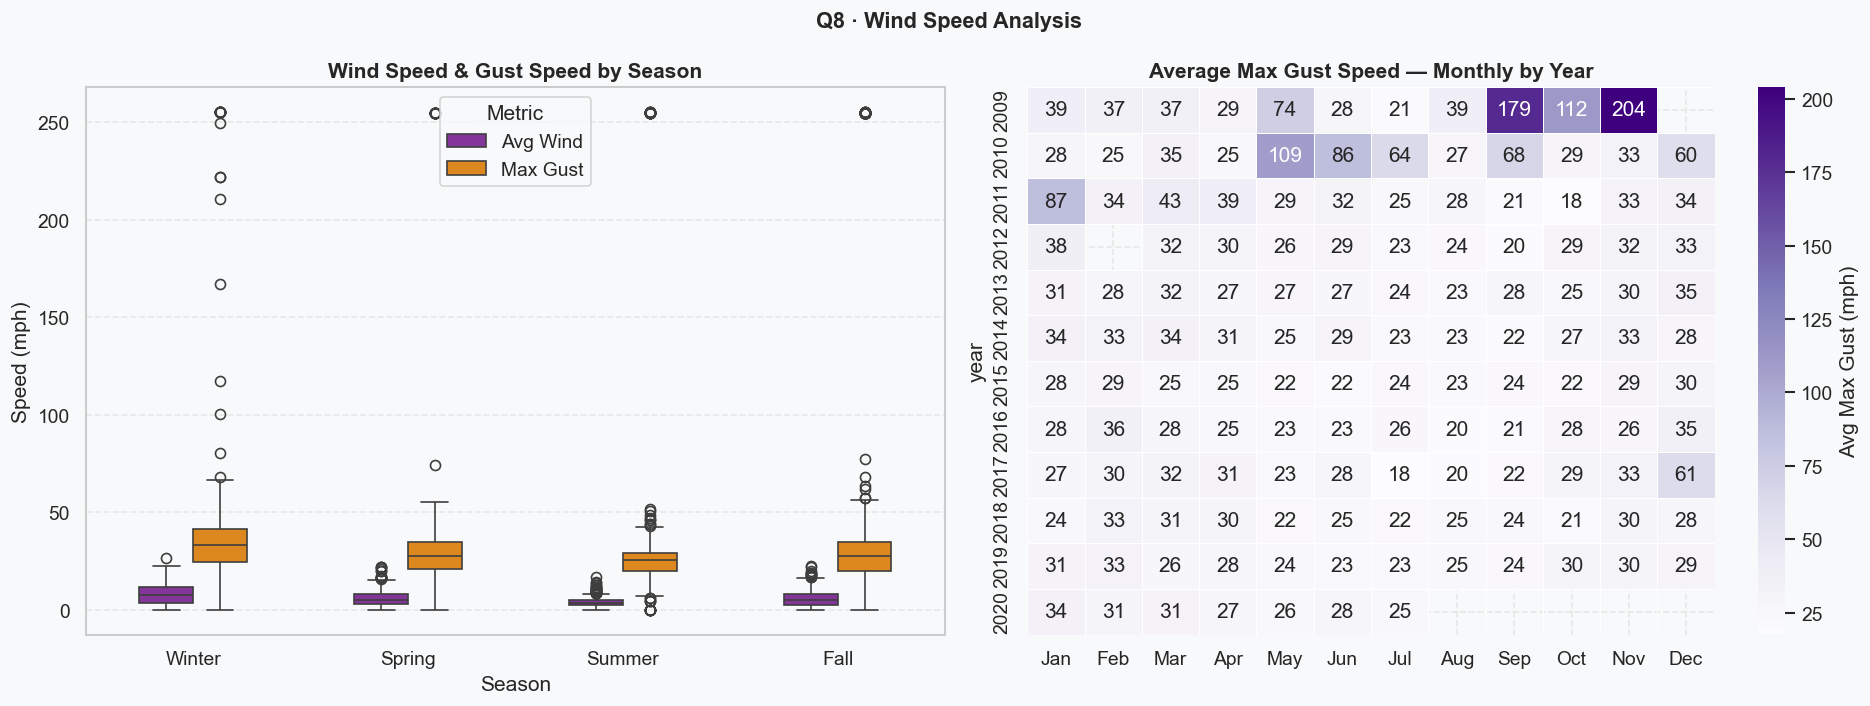

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Seasonal wind box plots ───────────────────────────────────────────────
ax = axes[0]
wind_melted = df.melt(id_vars='season',
                      value_vars=['avg_windspeed','max_gustspeed'],
                      var_name='Metric', value_name='Speed')
wind_melted['Metric'] = wind_melted['Metric'].map(
    {'avg_windspeed':'Avg Wind','max_gustspeed':'Max Gust'})
sns.boxplot(data=wind_melted, x='season', y='Speed', hue='Metric',
            order=season_order,
            palette={'Avg Wind':PALETTE['wind'],'Max Gust':PALETTE['neutral']},
            ax=ax, width=0.5)
ax.set_title('Wind Speed & Gust Speed by Season', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Speed (mph)')

# ── Monthly max gust heatmap ──────────────────────────────────────────────
ax2 = axes[1]
pivot_gust = df.pivot_table(values='max_gustspeed', index='year',
                            columns='month', aggfunc='mean').round(1)
pivot_gust.columns = MONTH_ABBR
sns.heatmap(pivot_gust, annot=True, fmt='.0f', cmap='Purples',
            linewidths=0.5, ax=ax2, cbar_kws={'label':'Avg Max Gust (mph)'})
ax2.set_title('Average Max Gust Speed — Monthly by Year', fontweight='bold')

fig.suptitle('Q8 · Wind Speed Analysis', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q8_wind_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()


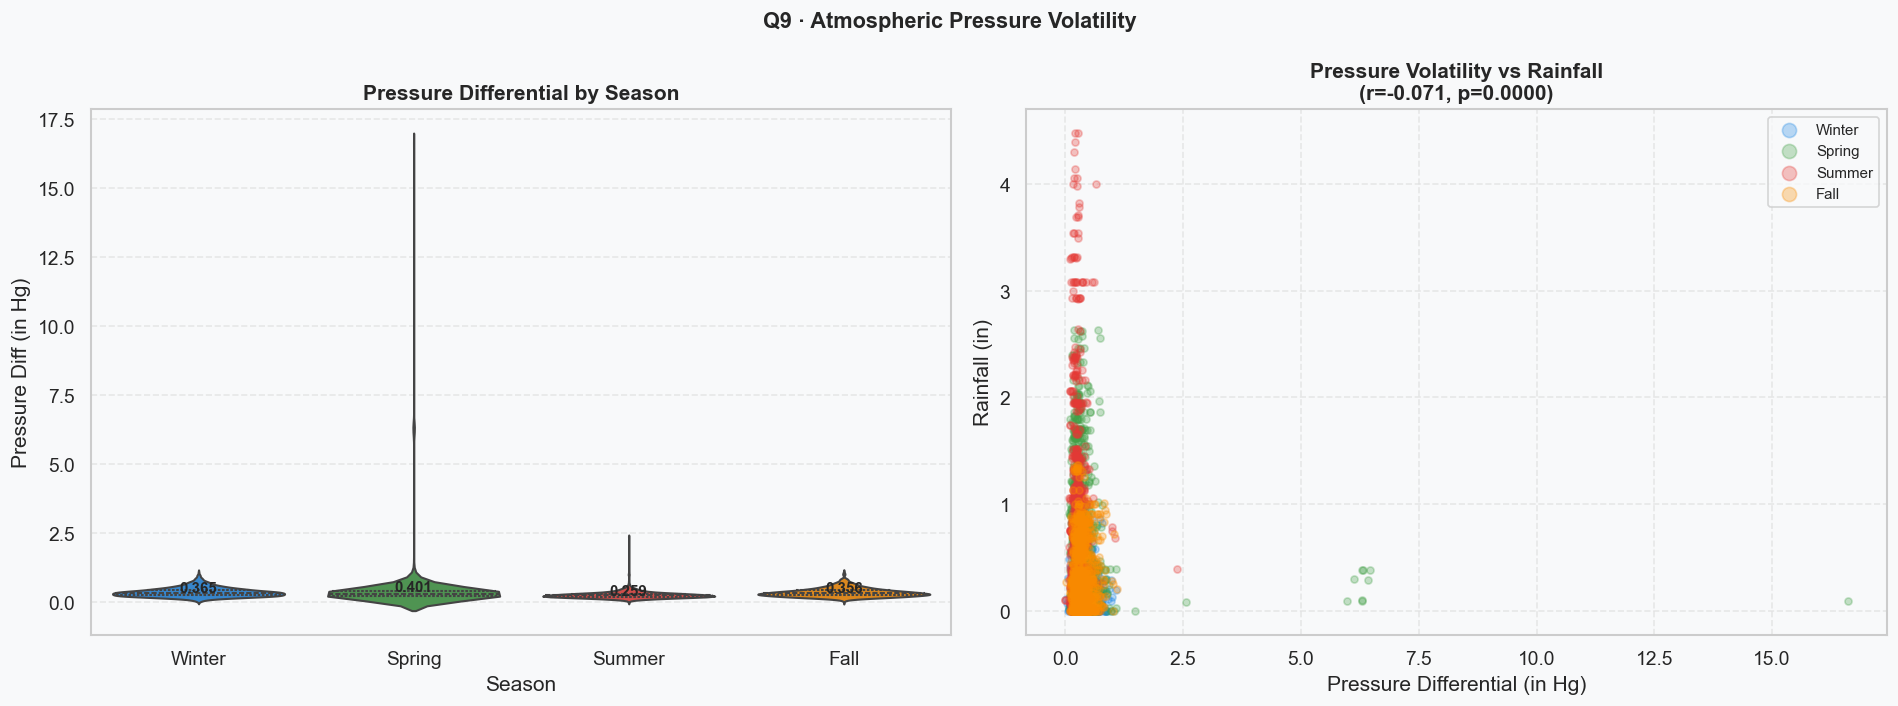

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Pressure diff distribution by season ─────────────────────────────────
ax = axes[0]
sns.violinplot(data=df, x='season', y='diff_pressure', order=season_order,
               palette=SEASON_COLORS, ax=ax, inner='quartile')
ax.set_title('Pressure Differential by Season', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Pressure Diff (in Hg)')
for i, s in enumerate(season_order):
    m = df[df['season']==s]['diff_pressure'].mean()
    ax.text(i, m+0.01, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# ── Pressure diff vs rainfall scatter ────────────────────────────────────
ax2 = axes[1]
for s in season_order:
    sub = df[df['season']==s]
    ax2.scatter(sub['diff_pressure'], sub['rainfall_month'],
                c=SEASON_COLORS[s], alpha=0.3, s=18, label=s)
ax2.set_xlabel('Pressure Differential (in Hg)')
ax2.set_ylabel('Rainfall (in)')
ax2.set_title('Pressure Volatility vs Rainfall', fontweight='bold')
ax2.legend(fontsize=9, markerscale=2)

r, p = stats.pearsonr(df['diff_pressure'], df['rainfall_month'])
ax2.set_title(f"""Pressure Volatility vs Rainfall
(r={r:.3f}, p={p:.4f})""",
              fontweight='bold')

fig.suptitle('Q9 · Atmospheric Pressure Volatility', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q9_pressure_volatility.png'),
            dpi=150, bbox_inches='tight')
plt.show()


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


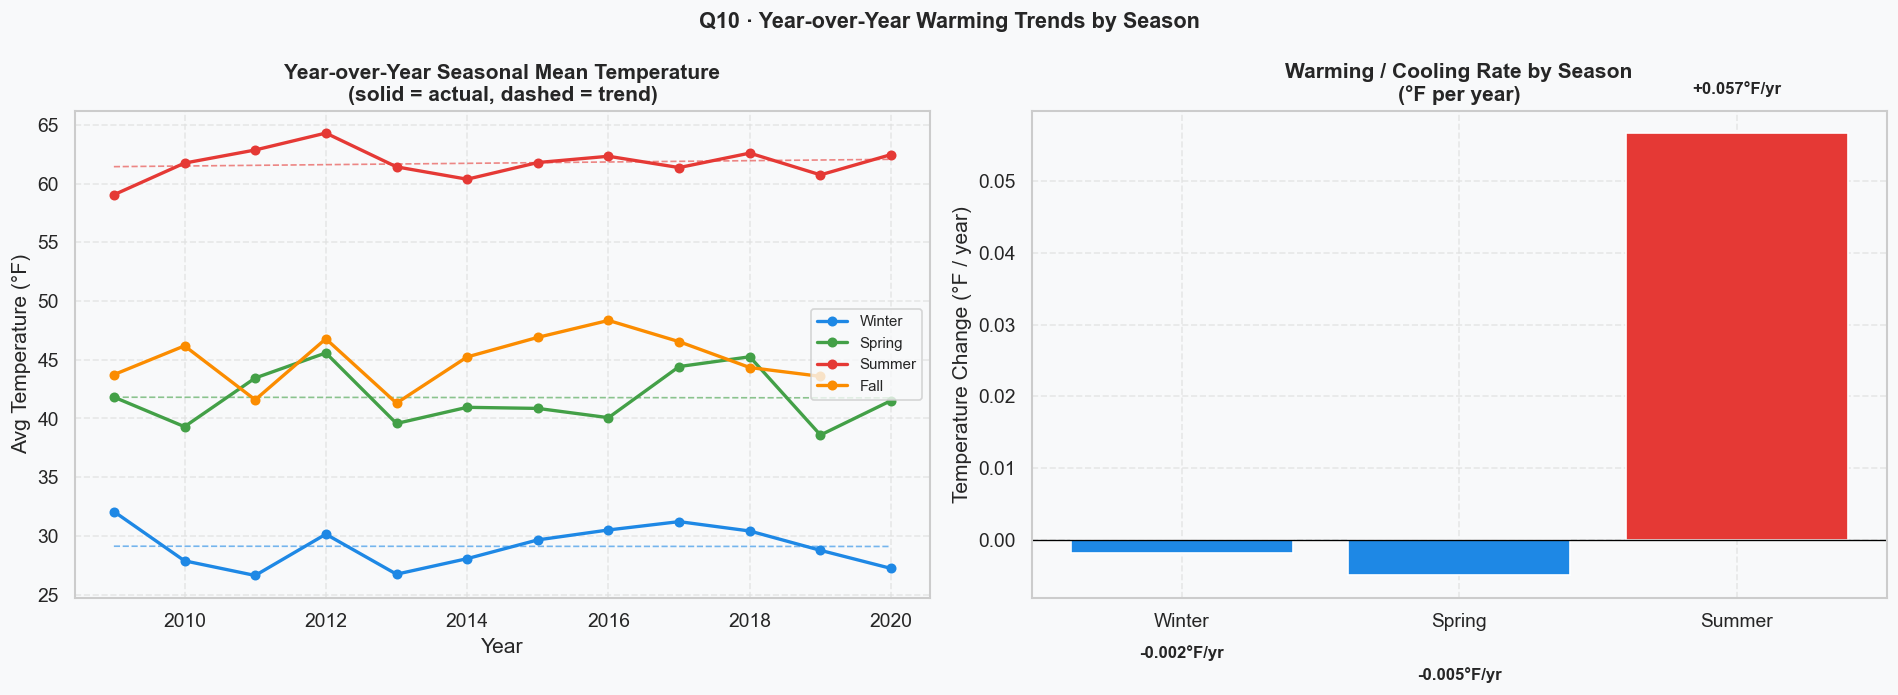


📊 Seasonal warming / cooling rates:
  Winter : -0.0019 °F/year  🔻 cooling
  Spring : -0.0050 °F/year  🔻 cooling
  Summer : +0.0567 °F/year  🔺 warming
  Fall   : +nan °F/year  🔻 cooling


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── YoY seasonal mean temperature lines ───────────────────────────────────
ax = axes[0]
yoy = df.groupby(['year','season'])['avg_temp'].mean().unstack()
for s in season_order:
    ax.plot(yoy.index, yoy[s], 'o-', color=SEASON_COLORS[s],
            linewidth=2, markersize=5, label=s)
    # Trend line
    sl, ic, _, _, _ = stats.linregress(yoy.index, yoy[s])
    ax.plot(yoy.index, sl*yoy.index + ic, '--',
            color=SEASON_COLORS[s], linewidth=1, alpha=0.6)
ax.set_title("""Year-over-Year Seasonal Mean Temperature
(solid = actual, dashed = trend)""",
             fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Temperature (°F)')
ax.legend(fontsize=9)

# ── Warming/cooling rate bar chart ────────────────────────────────────────
ax2 = axes[1]
slopes = {}
for s in season_order:
    sl, _, _, _, _ = stats.linregress(yoy.index, yoy[s])
    slopes[s] = sl   # °F per year

colors_slope = [PALETTE['hot'] if v>0 else PALETTE['cold'] for v in slopes.values()]
bars = ax2.bar(slopes.keys(), slopes.values(), color=colors_slope, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, slopes.values()):
    ypos = val + 0.005 if val >= 0 else val - 0.015
    ax2.text(bar.get_x()+bar.get_width()/2, ypos,
             f'{val:+.3f}°F/yr', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title("""Warming / Cooling Rate by Season
(°F per year)""", fontweight='bold')
ax2.set_ylabel('Temperature Change (°F / year)')

fig.suptitle('Q10 · Year-over-Year Warming Trends by Season', fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q10_yoy_warming.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Seasonal warming / cooling rates:')
for s, sl in slopes.items():
    direction = '🔺 warming' if sl > 0 else '🔻 cooling'
    print(f'  {s:7s}: {sl:+.4f} °F/year  {direction}')


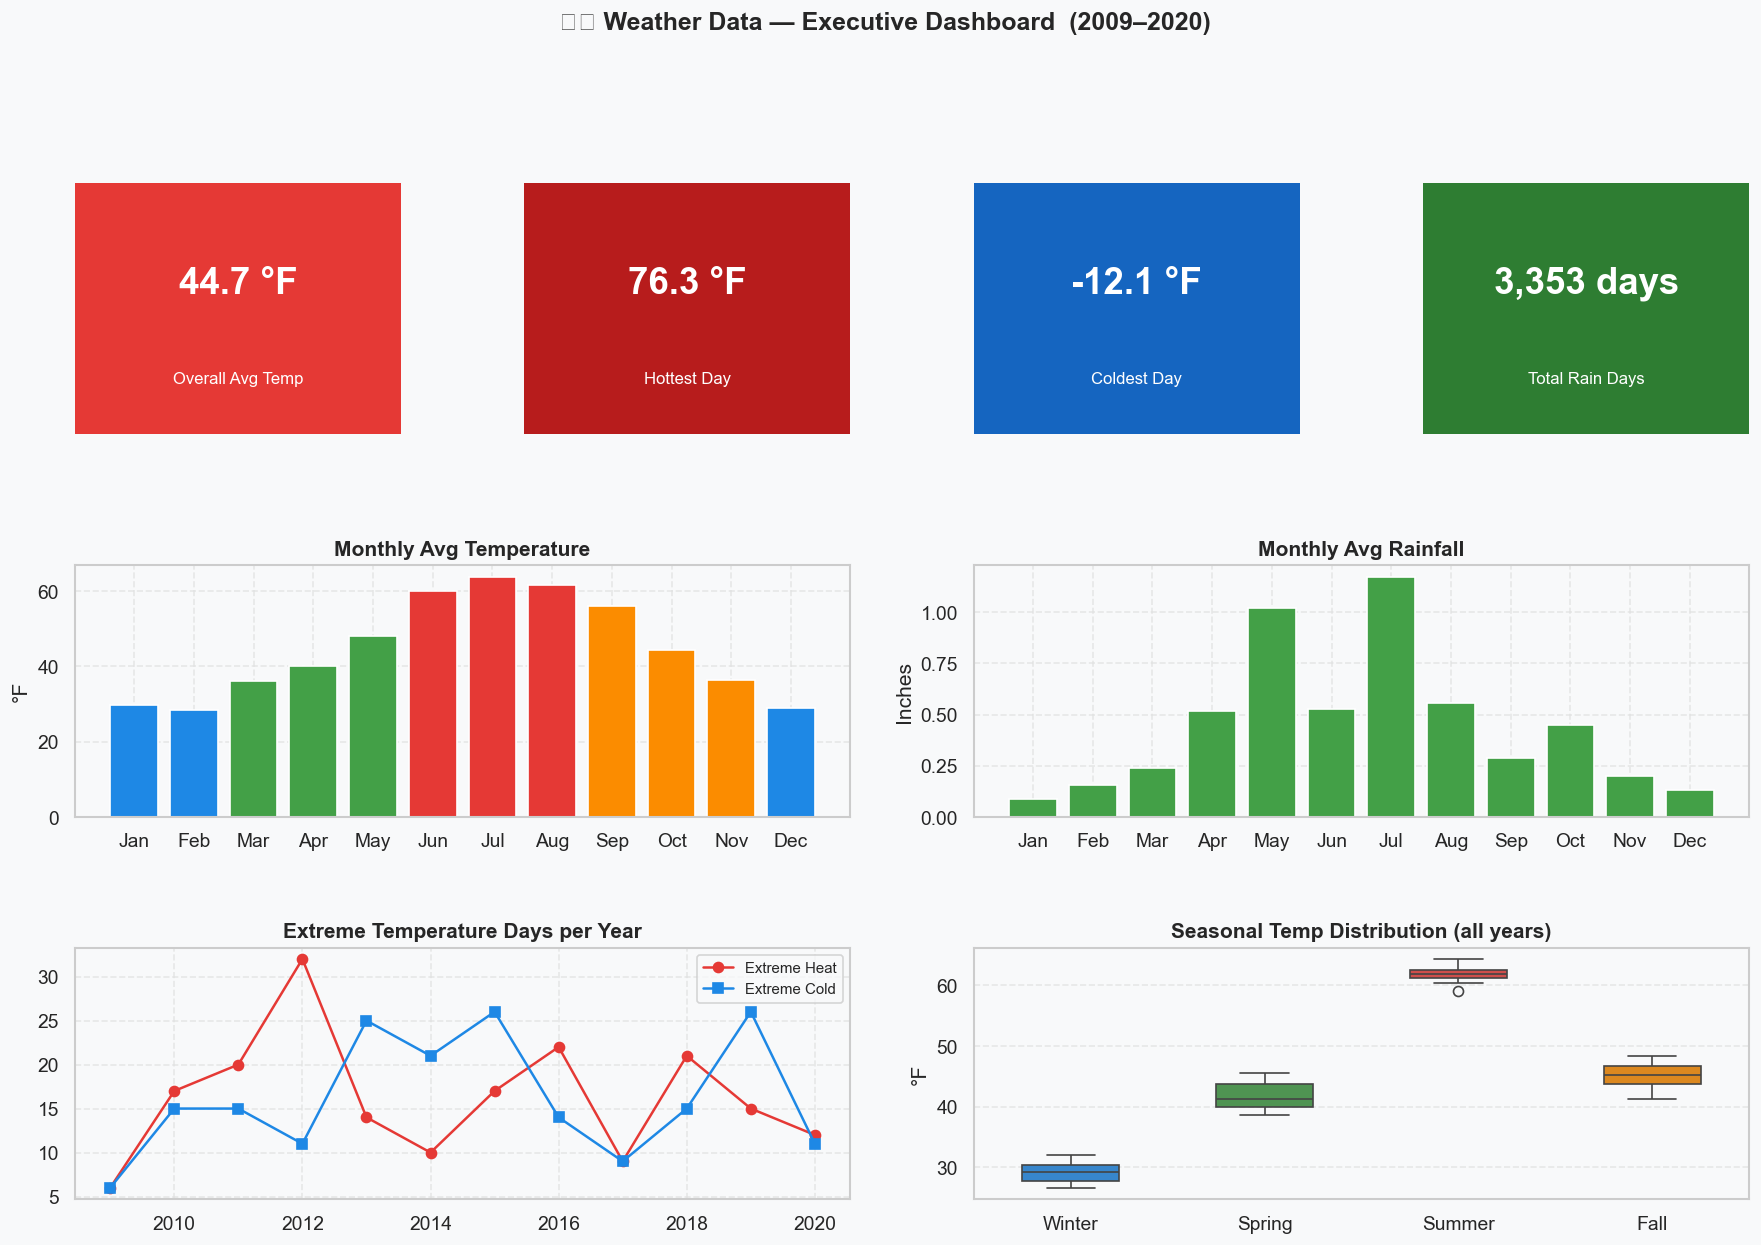

In [28]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(PALETTE['bg'])
gs = fig.add_gridspec(3, 4, hspace=0.52, wspace=0.38)

# ── KPI Tiles ─────────────────────────────────────────────────────────────
kpis = [
    ('Overall Avg Temp',  f"{df['avg_temp'].mean():.1f} °F",      '#E53935'),
    ('Hottest Day',       f"{df['avg_temp'].max():.1f} °F",        '#B71C1C'),
    ('Coldest Day',       f"{df['avg_temp'].min():.1f} °F",        '#1565C0'),
    ('Total Rain Days',   f"{df['has_rain'].sum():,} days",        '#2E7D32'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, val, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Mini: monthly avg temp ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
m_temp = df.groupby('month')['avg_temp'].mean()
ax1.bar(MONTH_ABBR, m_temp.values,
        color=[season_color_map[m] for m in range(1,13)], edgecolor='white')
ax1.set_title('Monthly Avg Temperature', fontweight='bold')
ax1.set_ylabel('°F')

# ── Mini: monthly rainfall ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
m_rain = df.groupby('month')['rainfall_month'].mean()
ax2.bar(MONTH_ABBR, m_rain.values, color=PALETTE['rain'], edgecolor='white')
ax2.set_title('Monthly Avg Rainfall', fontweight='bold')
ax2.set_ylabel('Inches')

# ── Mini: extreme events per year ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0:2])
ext = df.groupby('year')[['extreme_heat','extreme_cold']].sum()
ax3.plot(ext.index, ext['extreme_heat'], 'o-', color=PALETTE['hot'],  label='Extreme Heat')
ax3.plot(ext.index, ext['extreme_cold'], 's-', color=PALETTE['cold'], label='Extreme Cold')
ax3.set_title('Extreme Temperature Days per Year', fontweight='bold')
ax3.legend(fontsize=9)

# ── Mini: seasonal temp violin strip ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:4])
season_means = df.groupby(['year','season'])['avg_temp'].mean().reset_index()
sns.boxplot(data=season_means, x='season', y='avg_temp', order=season_order,
            palette=SEASON_COLORS, ax=ax4, width=0.5)
ax4.set_title('Seasonal Temp Distribution (all years)', fontweight='bold')
ax4.set_xlabel(''); ax4.set_ylabel('°F')

fig.suptitle('🌦️ Weather Data — Executive Dashboard  (2009–2020)',
             fontsize=15, fontweight='bold', y=1.01)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [29]:
rows = []
for s in season_order:
    sub = df[df['season']==s]
    rows.append({
        'Season'          : s,
        'Days'            : len(sub),
        'Avg Temp (°F)'   : round(sub['avg_temp'].mean(), 1),
        'Max Temp (°F)'   : round(sub['max_temp'].max(), 1),
        'Min Temp (°F)'   : round(sub['min_temp'].min(), 1),
        'Avg Humidity (%)'    : round(sub['avg_humidity'].mean(), 1),
        'Avg Rainfall (in)'   : round(sub['rainfall_month'].mean(), 3),
        'Avg Wind (mph)'  : round(sub['avg_windspeed'].mean(), 1),
        'Extreme Heat Days': int(sub['extreme_heat'].sum()),
        'Extreme Cold Days': int(sub['extreme_cold'].sum()),
    })

summary_df = pd.DataFrame(rows).set_index('Season')
summary_df.style.background_gradient(cmap='RdYlBu_r', subset=['Avg Temp (°F)'])


,Days,Avg Temp (°F),Max Temp (°F),Min Temp (°F),Avg Humidity (%),Avg Rainfall (in),Avg Wind (mph),Extreme Heat Days,Extreme Cold Days
Season,,,,,,,,,
Winter,955,29.100000,65.600000,-27.700000,45.900000,0.122000,7.900000,0,150
Spring,976,41.600000,80.700000,-13.800000,51.500000,0.600000,5.800000,0,19
Summer,1024,61.700000,92.700000,14.200000,50.900000,0.742000,3.800000,183,0
Fall,947,45.100000,91.600000,-22.500000,46.900000,0.315000,5.600000,12,25
